## Deep Water ##

In flux by South, I use everything except Full South.  Not sure why that is true.  Here I am using Full South.  

In [234]:
import arrow
import cmocean.cm as cm
import copy
import datetime as dt
import glob
import importlib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import transport_functions as tf

In [49]:
importlib.reload(tf)

<module 'transport_functions' from '/ocean/sallen/allen/research/Meopar/ANALYSIS/analysis-susan/notebooks/Ariane/v202111/transport_functions.py'>

In [161]:
# previous version
fsals, ftransports, fdepths = np.array([]), np.array([]), np.array([])
fmonths = 4*np.ones_like(fsals)
fyears = 15*np.ones_like(fsals)

y = 15
month = {1:'jan', 2: 'feb', 3: 'mar', 4: 'apr', 5: 'may', 6: 'jun',
        7: 'jul', 8: 'aug', 9: 'sep', 10: 'oct', 11: 'nov', 12: 'dec'}

for m in month:
    newsals, newtransports, newdepths = tf.get_data_south(month[m], y)
    newmonths = m*np.ones_like(newsals)
    newyears = y*np.ones_like(newsals)
    fsals = np.concatenate((fsals, newsals))
    ftransports = np.concatenate((ftransports, newtransports))
    fdepths = np.concatenate((fdepths, newdepths))
    fmonths = np.concatenate((fmonths, newmonths))
    fyears = np.concatenate((fyears, newyears))

/data/sallen/results/Ariane/FullSouth/
/data/sallen/results/Ariane/FullSouth/
/data/sallen/results/Ariane/FullSouth/
/data/sallen/results/Ariane/FullSouth/
/data/sallen/results/Ariane/FullSouth/
/data/sallen/results/Ariane/FullSouth/
/data/sallen/results/Ariane/FullSouth/
/data/sallen/results/Ariane/FullSouth/
/data/sallen/results/Ariane/FullSouth/
/data/sallen/results/Ariane/FullSouth/
/data/sallen/results/Ariane/FullSouth/
/data/sallen/results/Ariane/FullSouth/


In [162]:
# v202111
sals, transports, depths = np.array([]), np.array([]), np.array([])
months = 4*np.ones_like(sals)
years = 15*np.ones_like(sals)

# use same as above
#y = 15
#month = {1:'jan', 2: 'feb', 3: 'mar', 4: 'apr', 5: 'may', 6: 'jun'}

for m in month:
    newsals, newtransports, newdepths = tf.get_data_south(month[m], y, 
                                                          thedir='/data/sallen/results/Ariane/v202111/FullSouth/')
    newmonths = m*np.ones_like(newsals)
    newyears = y*np.ones_like(newsals)
    sals = np.concatenate((sals, newsals))
    transports = np.concatenate((transports, newtransports))
    depths = np.concatenate((depths, newdepths))
    months = np.concatenate((months, newmonths))
    years = np.concatenate((years, newyears))

/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/


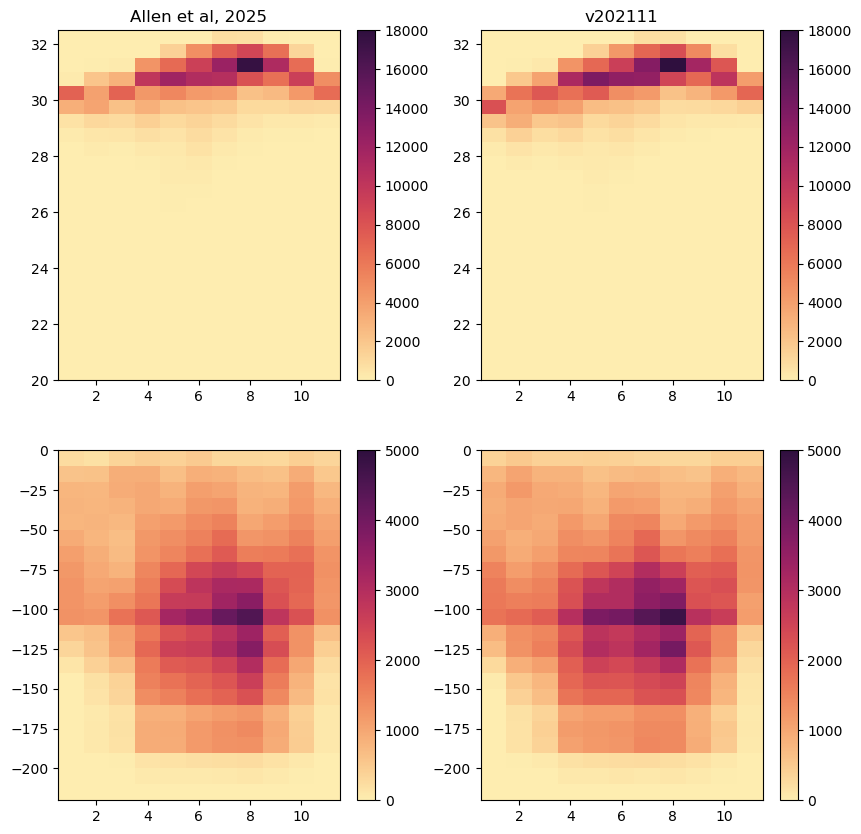

In [163]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
salt_bins = np.arange(20, 33, 0.5)
month_bins = np.arange(0.5, 12, 1)
depth_bins = np.arange(-220, 0.5, 10)
c, xedge, yedge, im = axs[0, 0].hist2d((fmonths), 
                                (fsals),
                                weights=(ftransports)/24/30.5/1.,  # 1 year only at this point
                                bins=[month_bins, salt_bins], cmap=cm.matter, vmax=18000)
fig.colorbar(im, ax=axs[0, 0]);
axs[0, 0].set_title('Allen et al, 2025')

c, xedge, yedge, im = axs[1, 0].hist2d((fmonths), 
                                (fdepths),
                                weights=(ftransports)/24/30.5/1.,  # 1 year only at this point
                                bins=[month_bins, depth_bins], cmap=cm.matter, vmax=5000)
fig.colorbar(im, ax=axs[1, 0]);

c, xedge, yedge, im = axs[0, 1].hist2d((months), 
                                (sals),
                                weights=(transports)/24/30.5/1.,  # 1 year only at this point
                                bins=[month_bins, salt_bins], cmap=cm.matter, vmax=18000)
fig.colorbar(im, ax=axs[0, 1]);
axs[0, 1].set_title('v202111')

c, xedge, yedge, im = axs[1, 1].hist2d((months), 
                                (depths),
                                weights=(transports)/24/30.5/1.,  # 1 year only at this point
                                bins=[month_bins, depth_bins], cmap=cm.matter, vmax=5000)
fig.colorbar(im, ax=axs[1, 1]);

In [248]:
# v202111, compare years
month = {1:'jan', 2: 'feb', 3: 'mar', 4: 'apr', 5: 'may', 6: 'jun'}
sals, transports, depths = np.array([]), np.array([]), np.array([])
months = 4*np.ones_like(sals)
years = 15*np.ones_like(sals)

years = [15, 16, 17, 20]

for y in years:
    print(y)
    for m in month:
        newsals, newtransports, newdepths = tf.get_data_south(month[m], y, 
                                                              thedir='/data/sallen/results/Ariane/v202111/FullSouth/')
        newmonths = m*np.ones_like(newsals)
        newyears = y*np.ones_like(newsals)
        sals = np.concatenate((sals, newsals))
        transports = np.concatenate((transports, newtransports))
        depths = np.concatenate((depths, newdepths))
        months = np.concatenate((months, newmonths))
        years = np.concatenate((years, newyears))

15
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
16
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
17
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
20
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/data/sallen/results/Ariane/v202111/FullSouth/
/

In [250]:
print (months.shape, years.shape)
iw = years.shape[0] - months.shape[0]
iw

(905848,) (905852,)


4

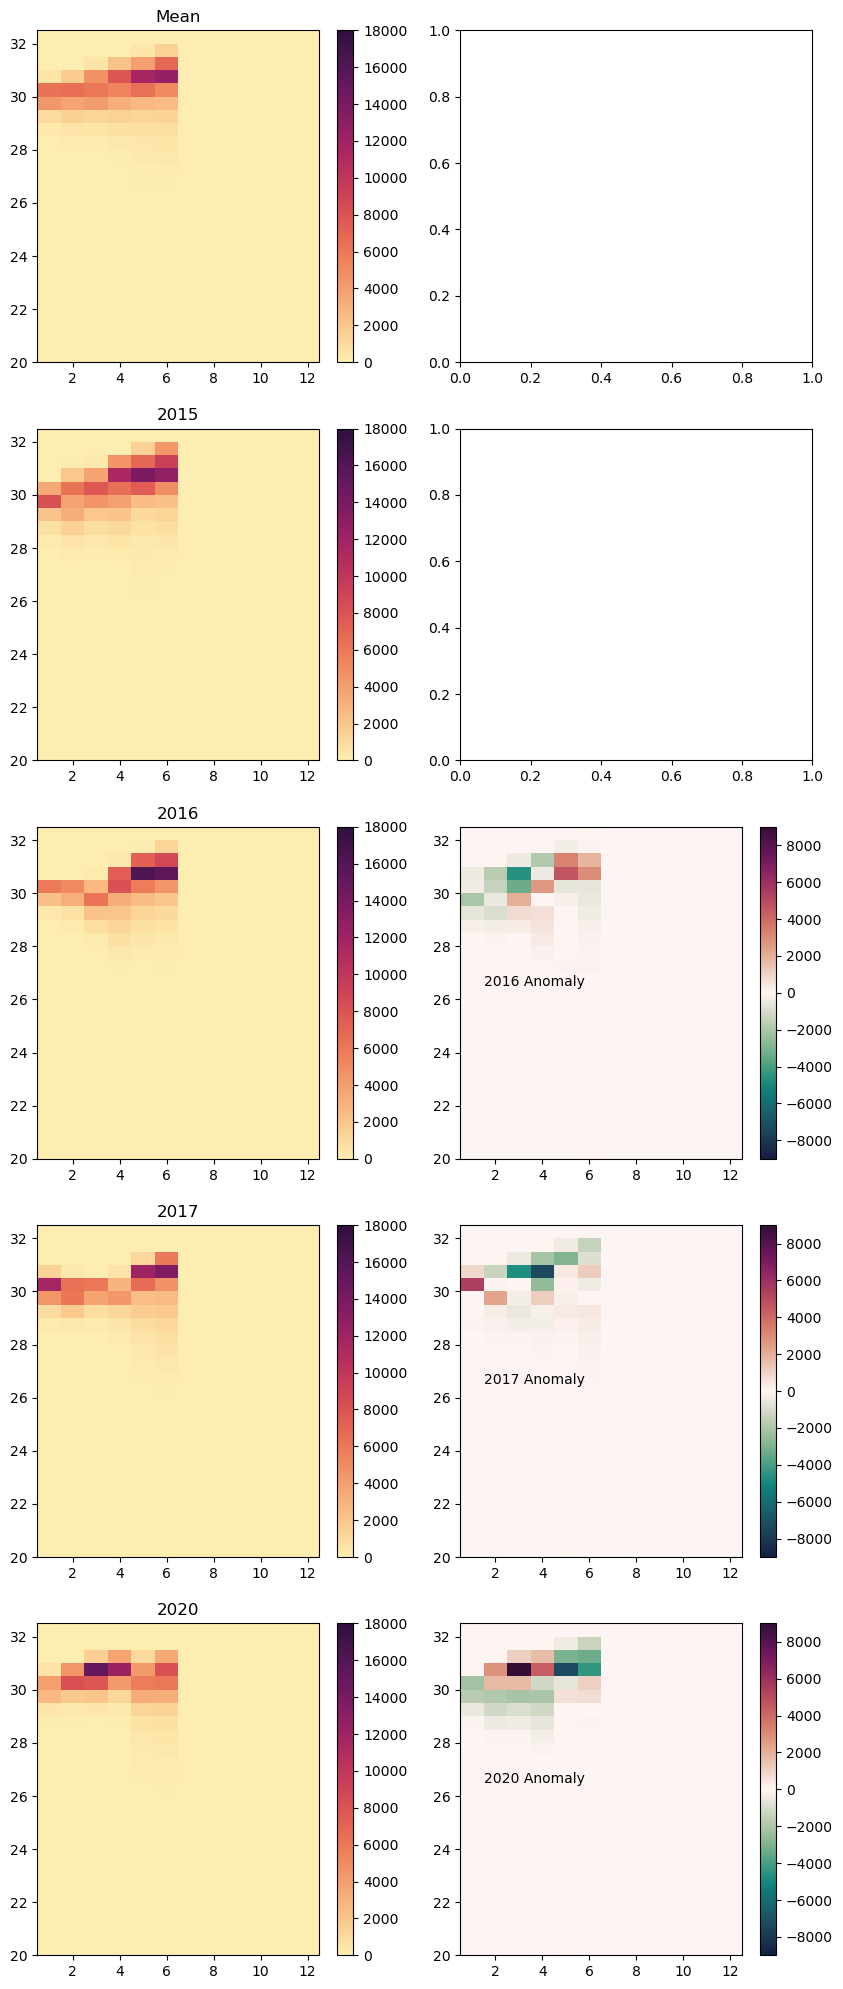

In [251]:
fig, axs = plt.subplots(5, 2, figsize=(10, 25))
vmax = 18000
av = 2
month_bins = np.arange(0.5, 13, 1)
cin_mean, xedge, yedge, im = axs[0, 0].hist2d((months), 
                                (sals),
                                weights=(transports)/24/30.5/4.,  # 4 years only at this point
                                bins=[month_bins, salt_bins], cmap=cm.matter, vmax=vmax)
fig.colorbar(im, ax=axs[0, 0]);
axs[0, 0].set_title('Mean')

year = 15
c, xedge, yedge, im = axs[1,0].hist2d((months[years[:-iw]==year]), 
                                (sals[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, salt_bins], cmap=cm.matter, vmax=vmax)
fig.colorbar(im, ax=axs[1, 0]);
axs[1, 0].set_title('2015')

year = 16
ir = 2
c, xedge, yedge, im = axs[ir, 0].hist2d((months[years[:-iw]==year]), 
                                (sals[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, salt_bins], cmap=cm.matter, vmax=vmax)
fig.colorbar(im, ax=axs[ir, 0]);
axs[ir, 0].set_title(f'20{year}')

c, xedge, yedge = np.histogram2d((months[years[:-iw]==year]), 
                                (sals[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, salt_bins])
im2 = axs[ir, 1].pcolormesh(xedge, yedge, (c-cin_mean).transpose(), cmap=cm.curl, vmax=vmax/av, vmin=-vmax/av)
fig.colorbar(im2, ax=axs[ir, 1]);
axs[ir, 1].text(1.5, 26.5, f'20{year} Anomaly');

year = 17
ir = 3
c, xedge, yedge, im = axs[ir, 0].hist2d((months[years[:-iw]==year]), 
                                (sals[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, salt_bins], cmap=cm.matter, vmax=vmax)
fig.colorbar(im, ax=axs[ir, 0]);
axs[ir, 0].set_title('2017')

c, xedge, yedge = np.histogram2d((months[years[:-iw]==year]), 
                                (sals[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, salt_bins])
im2 = axs[ir, 1].pcolormesh(xedge, yedge, (c-cin_mean).transpose(), cmap=cm.curl, vmax=vmax/av, vmin=-vmax/av)
fig.colorbar(im2, ax=axs[ir, 1]);
axs[ir, 1].text(1.5, 26.5, '2017 Anomaly');

year = 20
ir = 4
c, xedge, yedge, im = axs[ir, 0].hist2d((months[years[:-iw]==year]), 
                                (sals[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, salt_bins], cmap=cm.matter, vmax=vmax)
fig.colorbar(im, ax=axs[ir, 0]);
axs[ir, 0].set_title('2020')

c, xedge, yedge = np.histogram2d((months[years[:-iw]==year]), 
                                (sals[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, salt_bins])
im2 = axs[ir, 1].pcolormesh(xedge, yedge, (c-cin_mean).transpose(), cmap=cm.curl, vmax=vmax/av, vmin=-vmax/av)
fig.colorbar(im2, ax=axs[ir, 1]);
axs[ir, 1].text(1.5, 26.5, '2020 Anomaly');

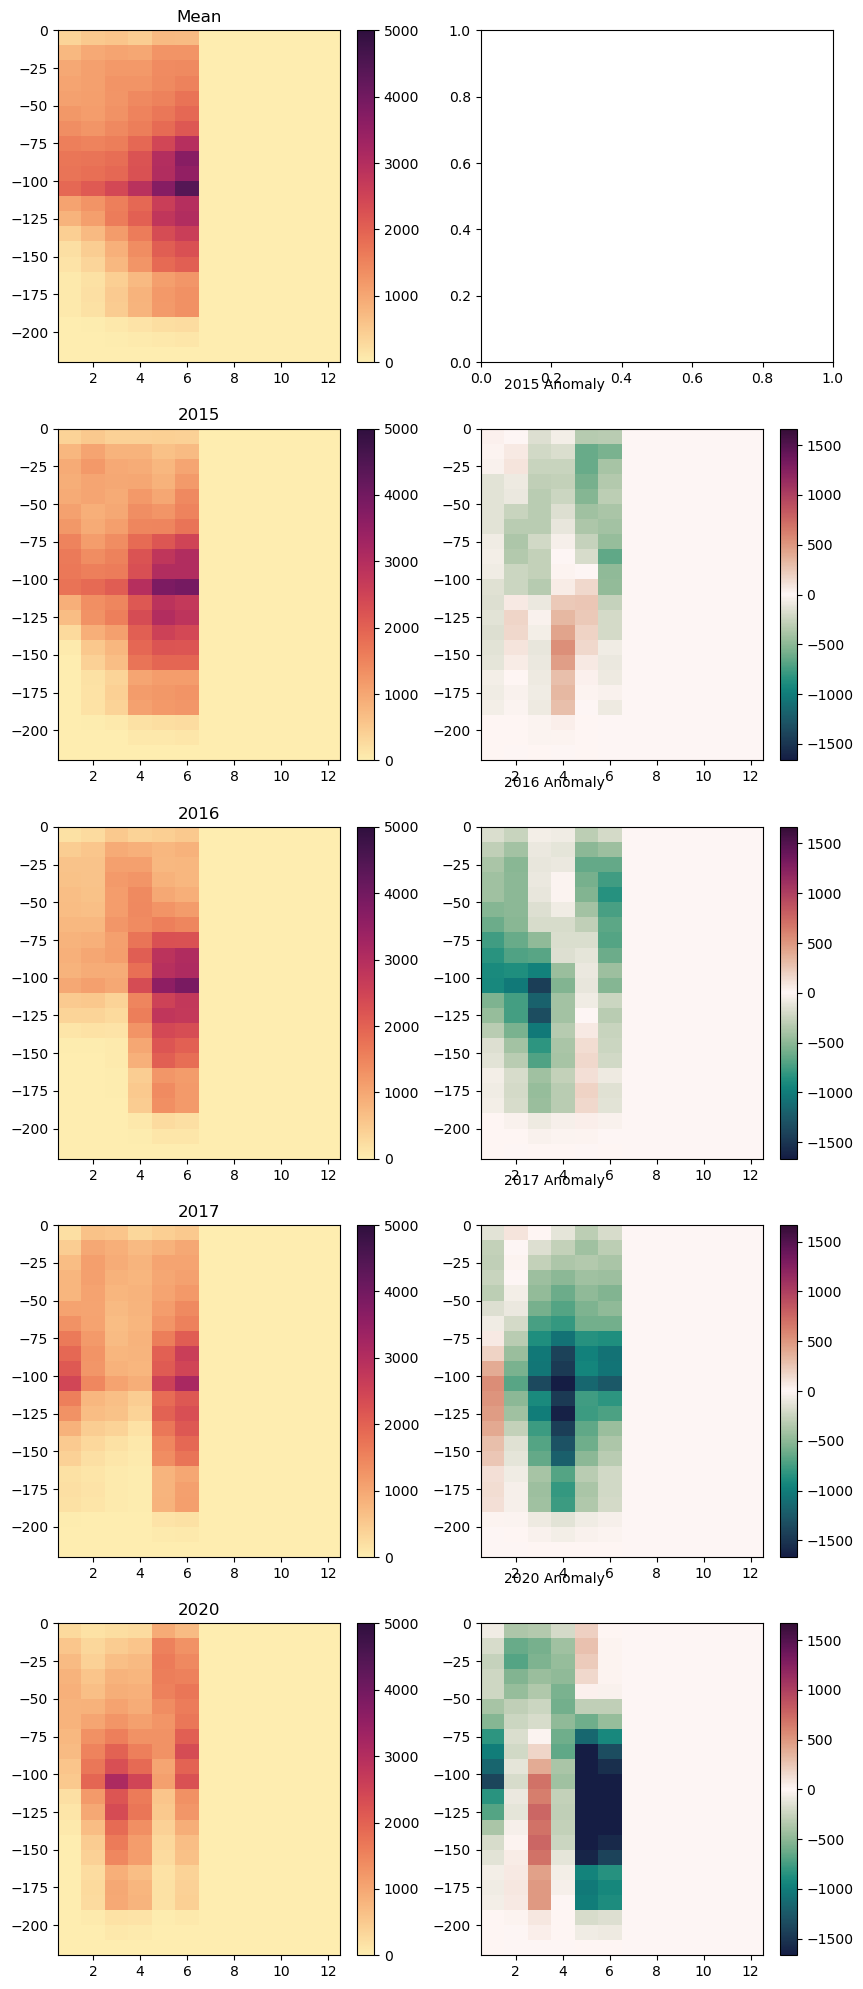

In [252]:
fig, axs = plt.subplots(5, 2, figsize=(10, 25))
#month_bins = np.arange(0.5, 6, 1)
vmax = 5000
av = 3
cin_mean, xedge, yedge, im = axs[0, 0].hist2d((months), 
                                (depths),
                                weights=(transports)/24/30.5/3.,  # 3 years only at this point
                                bins=[month_bins, depth_bins], cmap=cm.matter, vmax=vmax)
fig.colorbar(im, ax=axs[0, 0]);
axs[0, 0].set_title('Mean')

year = 15
c, xedge, yedge, im = axs[1,0].hist2d((months[years[:-iw]==year]), 
                                (depths[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, depth_bins], cmap=cm.matter, vmax=vmax)
fig.colorbar(im, ax=axs[1, 0]);
axs[1, 0].set_title('2015')

c, xedge, yedge = np.histogram2d((months[years[:-iw]==year]), 
                                (depths[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, depth_bins])
im2 = axs[1, 1].pcolormesh(xedge, yedge, (c-cin_mean).transpose(), cmap=cm.curl, vmax=vmax/av, vmin=-vmax/av)
fig.colorbar(im2, ax=axs[1, 1]);
axs[1, 1].text(1.5, 26.5, '2015 Anomaly');

year = 16
ir = 2
c, xedge, yedge, im = axs[ir, 0].hist2d((months[years[:-iw]==year]), 
                                (depths[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, depth_bins], cmap=cm.matter, vmax=vmax)
fig.colorbar(im, ax=axs[ir, 0]);
axs[ir, 0].set_title(f'20{year}')

c, xedge, yedge = np.histogram2d((months[years[:-iw]==year]), 
                                (depths[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, depth_bins])
im2 = axs[ir, 1].pcolormesh(xedge, yedge, (c-cin_mean).transpose(), cmap=cm.curl, vmax=vmax/av, vmin=-vmax/av)
fig.colorbar(im2, ax=axs[ir, 1]);
axs[ir, 1].text(1.5, 26.5, f'20{year} Anomaly');

year = 17
ir = 3
c, xedge, yedge, im = axs[ir, 0].hist2d((months[years[:-iw]==year]), 
                                (depths[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, depth_bins], cmap=cm.matter, vmax=vmax)
fig.colorbar(im, ax=axs[ir, 0]);
axs[ir, 0].set_title(f'20{year}')

c, xedge, yedge = np.histogram2d((months[years[:-iw]==year]), 
                                (depths[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, depth_bins])
im2 = axs[ir, 1].pcolormesh(xedge, yedge, (c-cin_mean).transpose(), cmap=cm.curl, vmax=vmax/av, vmin=-vmax/av)
fig.colorbar(im2, ax=axs[ir, 1]);
axs[ir, 1].text(1.5, 26.5, f'20{year} Anomaly');

year = 20
ir = 4
c, xedge, yedge, im = axs[ir, 0].hist2d((months[years[:-iw]==year]), 
                                (depths[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, depth_bins], cmap=cm.matter, vmax=vmax)
fig.colorbar(im, ax=axs[ir, 0]);
axs[ir, 0].set_title('2020')

c, xedge, yedge = np.histogram2d((months[years[:-iw]==year]), 
                                (depths[years[:-iw]==year]),
                                weights=(transports[years[:-iw]==year])/24/30.5,
                                bins=[month_bins, depth_bins])
im2 = axs[ir, 1].pcolormesh(xedge, yedge, (c-cin_mean).transpose(), cmap=cm.curl, vmax=vmax/av, vmin=-vmax/av)
fig.colorbar(im2, ax=axs[ir, 1]);
axs[ir, 1].text(1.5, 26.5, '2020 Anomaly');

In [236]:
section = 2
thedir = '/data/sallen/results/Ariane/v202111/FullSouth/'
year = 2017
start = dt.datetime(year, 2, 1)
endtime = dt.datetime(year, 12, 31)
timerange = arrow.Arrow.range('day', start, endtime)
tsals = np.zeros((365-31))
ttransports = np.zeros_like(tsals)
tdepths = np.zeros_like(tsals)
deep_transports = np.zeros_like(tsals)

for i, r in enumerate(timerange):
    filename = (thedir+r.format('DDMMMYY').lower()+'/ariane_positions_quantitative.nc')
    mydata = xr.open_dataset(filename)
    sals = mydata.final_salt[(mydata.final_section==section)]
    transports = mydata.final_transp[(mydata.final_section==section)]
    depths = mydata.final_depth[(mydata.final_section==section)]
    tsals[i] = np.sum(sals*transports)/np.sum(transports)
    ttransports[i] = np.sum(transports)/24.
    deep_transports[i] = np.sum(mydata.final_transp[(mydata.final_section==section) &
                                                    (mydata.final_depth <= -100)])/24.
    tdepths[i] = np.sum(depths*transports)/np.sum(transports)
    if i == 0:
        bsals = sals
        btransports = transports
        bdepths = depths
        bdays = np.ones_like(depths)
        print (bdepths.shape, bdays.shape)
    else:
        bsals = np.concatenate((bsals, sals))
        btransports = np.concatenate((btransports, transports))
        bdepths = np.concatenate((bdepths, depths))
        bdays = np.concatenate((bdays, i*np.ones_like(depths)))

(1105,) (1105,)


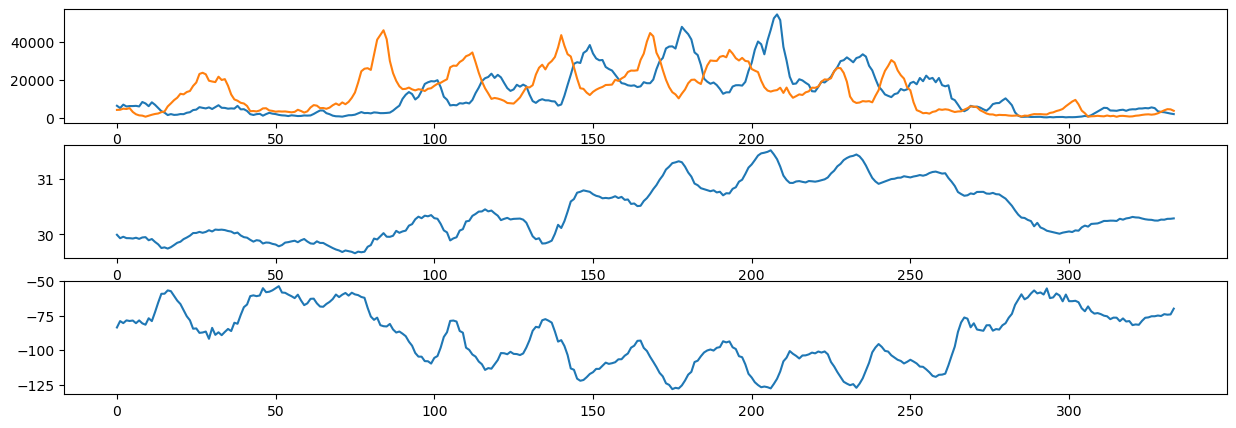

In [238]:
fig, axs = plt.subplots(3, 1, figsize=(15, 5))
axs[1].plot(tsals)
#axs[0].plot(ttransports)
axs[0].plot(deep_transports)
axs[0].plot(deep_transports_2015)
axs[2].plot(tdepths);

In [235]:
deep_transports_2015 = copy.copy(deep_transports)

In [239]:
deep_transports_2017 = copy.copy(deep_transports)

In [190]:
print (bdepths.shape, btransports.shape, bsals.shape, bdays.shape)

(67226,) (67226,) (67226,) (67226,)


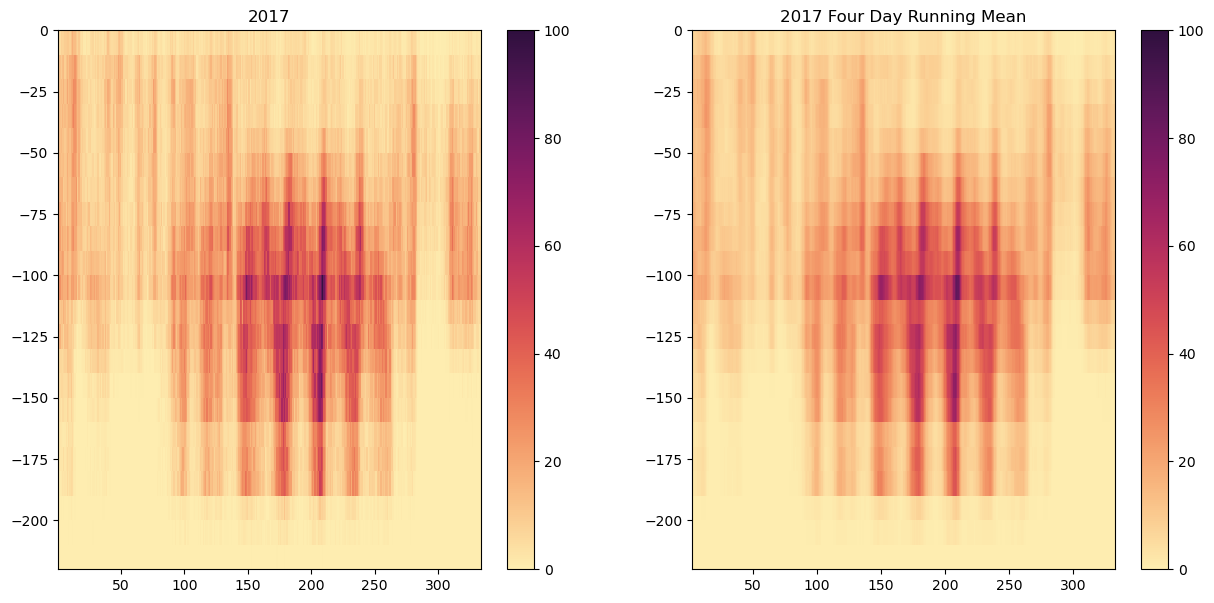

In [246]:
day_bins = np.arange(0.5, 365-31, 1)
fig, axs = plt.subplots(1, 2, figsize=(15,7))
cin_mean, xedge, yedge, im = axs[0].hist2d((bdays), 
                                (bdepths),
                                weights=(btransports)/24/30.5/3.,  # 3 years only at this point
                                bins=[day_bins, depth_bins], cmap=cm.matter, vmax=100)
fig.colorbar(im, ax=axs[0]);
axs[0].set_title(year)

running_mean_matrix = np.apply_along_axis(
    lambda row: np.convolve(row, weights, mode='valid'), 
    axis=0, 
    arr=cin_mean
)

im2 = axs[1].pcolormesh(xedge[2:-1], yedge, running_mean_matrix.transpose(), 
                                                     cmap=cm.matter, vmax=100)
fig.colorbar(im2, ax=axs[1]);
axs[1].set_title(f'{year} Four Day Running Mean');

## The Money Plot (Cum Sum) ##

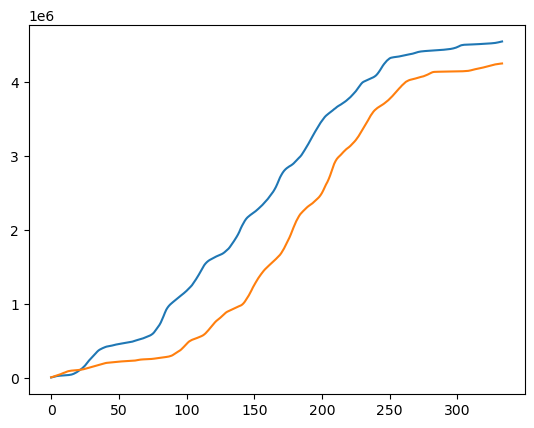

In [247]:
plt.plot(np.cumsum(deep_transports_2015))
plt.plot(np.cumsum(deep_transports_2017));

So now make it nice!
* patch missing days
* get the date to work (including skipping Feb 26 in 2016 and 2020)

# New notebook time! #